CUSTOMER CHURN PREDICTION

1. IMPORT LIBRARIES

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

2. DATA COLLECTION

In [27]:
from google.colab import files
uploaded = files.upload()

Saving churn prediction.csv to churn prediction (1).csv


In [54]:
df = pd.read_csv("churn prediction.csv")

3. DATA PREPARATION

In [55]:
df.head()

,CustomerID,Age,Gender,Income,SpendingScore,PurchaseAmount,ProductCategory,PaymentMethod,City,State,Country,LastPurchaseDate,IsActive,Returns,DiscountUsed,ReviewScore,Browser,Device,SessionTime,Churn
0,210,41,Female,35167,65,3992,Beauty,UPI,Delhi,DL,IND,2023-01-01,Y,2.0,False,3.315200,NaN,Desktop,253,No
1,328,63,M,20636,38,4968,Clothing,Card,Hyderabad,TN,India,NaN,No,0.0,False,2.189086,Edge,Mobile,214,Yes
2,4212,34,NaN,29854,78,2807,Clothing,UPI,Delhi,MH,IN,01/02/2023,N,2.0,NaN,3.760838,Chrome,Mobile,61,Yes
3,3054,54,NaN,108678,82,3305,Beauty,Cash,Chennai,DL,IND,March 5 2023,NaN,2.0,NaN,3.188211,Chrome,Mobile,167,Yes
4,4620,67,Female,114929,49,4407,NaN,Card,Hyderabad,NaN,IND,2023-01-01,N,NaN,False,3.003102,Firefox,NaN,296,Yes


In [56]:
df.tail()

,CustomerID,Age,Gender,Income,SpendingScore,PurchaseAmount,ProductCategory,PaymentMethod,City,State,Country,LastPurchaseDate,IsActive,Returns,DiscountUsed,ReviewScore,Browser,Device,SessionTime,Churn
5195,2732,50,Male,28120,62,3390,Beauty,UPI,Chennai,DL,NaN,01/02/2023,Yes,0.0,True,1.595264,Edge,Tablet,85,No
5196,2805,56,Male,80695,89,1042,Electronics,NetBanking,Mumbai,TS,IN,2023-01-01,N,0.0,NaN,1.089155,Edge,Mobile,85,Yes
5197,3793,46,Female,74380,45,3399,Electronics,UPI,NaN,TN,IND,2023-01-01,N,2.0,NaN,2.574446,Firefox,Desktop,205,Yes
5198,2969,48,Female,115842,21,1013,NaN,UPI,Chennai,TN,IND,01/02/2023,No,NaN,False,4.715468,Edge,Tablet,140,No
5199,2721,44,Female,45143,50,951,Clothing,Cash,Hyderabad,NaN,NaN,March 5 2023,NaN,NaN,True,1.259648,Chrome,Mobile,267,Yes


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        5200 non-null   int64  
 1   Age               5200 non-null   int64  
 2   Gender            4162 non-null   object 
 3   Income            5200 non-null   int64  
 4   SpendingScore     5200 non-null   int64  
 5   PurchaseAmount    5200 non-null   int64  
 6   ProductCategory   4083 non-null   object 
 7   PaymentMethod     4082 non-null   object 
 8   City              4142 non-null   object 
 9   State             4222 non-null   object 
 10  Country           3925 non-null   object 
 11  LastPurchaseDate  3845 non-null   object 
 12  IsActive          4120 non-null   object 
 13  Returns           3913 non-null   float64
 14  DiscountUsed      3534 non-null   object 
 15  ReviewScore       5200 non-null   float64
 16  Browser           3851 non-null   object 


In [58]:
df.describe()

,CustomerID,Age,Income,SpendingScore,PurchaseAmount,Returns,ReviewScore,SessionTime
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,3913.000000,5200.000000,5200.000000
mean,2504.226154,43.629808,69774.555192,49.416154,2524.003462,0.997700,3.009745,150.256923
std,1443.535621,14.910404,29109.719142,28.477982,1411.886954,0.813514,1.146835,85.487746
min,1.000000,18.000000,20005.000000,1.000000,100.000000,0.000000,1.000516,1.000000
25%,1260.750000,31.000000,44062.500000,24.000000,1317.750000,0.000000,2.040605,77.000000
50%,2507.500000,44.000000,70216.500000,50.000000,2502.000000,1.000000,3.000984,151.000000
75%,3753.250000,56.000000,94716.000000,74.000000,3723.000000,2.000000,3.999873,223.000000
max,5000.000000,69.000000,119981.000000,99.000000,4999.000000,2.000000,4.999446,299.000000


In [59]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Income', 'SpendingScore',
       'PurchaseAmount', 'ProductCategory', 'PaymentMethod', 'City', 'State',
       'Country', 'LastPurchaseDate', 'IsActive', 'Returns', 'DiscountUsed',
       'ReviewScore', 'Browser', 'Device', 'SessionTime', 'Churn'],
      dtype='object')

In [60]:
df.shape

(5200, 20)

In [61]:
df.size

104000

4. DATA CLEANING

Handle Null Values

In [62]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,1038
Income,0
SpendingScore,0
PurchaseAmount,0
ProductCategory,1117
PaymentMethod,1118
City,1058
State,978


In [63]:
# Fill numeric with mean
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_49903/3571404093.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_49903/3571404093.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [64]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
SpendingScore,0
PurchaseAmount,0
ProductCategory,0
PaymentMethod,0
City,0
State,0


Remove Duplicates

In [65]:
df.drop_duplicates(inplace=True)

Fix formats

In [66]:
df['IsActive'] = df['IsActive'].map({
    'Y': 1,
    'N': 0,
    'Yes': 1,
    'No': 0
})

In [67]:
df['Gender'] = df['Gender'].str.lower().replace({
    'm': 'male',
    'f': 'female'
})

Fix country

In [68]:
df['Country'] = df['Country'].str.strip().str.upper()

df['Country'] = df['Country'].replace({
    'IND': 'INDIA',
    'IN': 'INDIA'
})

Fix Churn (TARGET)

In [69]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

5. FEATURE ENGINEERING

convert date

In [70]:
df['LastPurchaseDate'] = pd.to_datetime(
    df['LastPurchaseDate'],
    format='mixed',   # handles multiple formats
    dayfirst=True     # important for 01-02-2023 → 1 Feb (not Jan 2)
)

In [71]:
print(df['LastPurchaseDate'].isnull().sum())

0


In [72]:
df['days_since_purchase'] = (
    pd.Timestamp.today() - df['LastPurchaseDate']
).dt.days

In [73]:
df.drop('LastPurchaseDate', axis=1, inplace=True)

In [74]:
print(df.isnull().sum())

CustomerID             0
Age                    0
Gender                 0
Income                 0
SpendingScore          0
PurchaseAmount         0
ProductCategory        0
PaymentMethod          0
City                   0
State                  0
Country                0
IsActive               0
Returns                0
DiscountUsed           0
ReviewScore            0
Browser                0
Device                 0
SessionTime            0
Churn                  0
days_since_purchase    0
dtype: int64


Encoding categorical variables

In [75]:
df = pd.get_dummies(df, drop_first=True)

drop unnecessary features

In [88]:
cols_to_drop = [col for col in df.columns if col.startswith(('City_', 'State_', 'Browser_'))]

df.drop(cols_to_drop, axis=1, inplace=True)

In [89]:
print(df.columns)

Index(['CustomerID', 'Age', 'Income', 'SpendingScore', 'PurchaseAmount',
       'IsActive', 'Returns', 'DiscountUsed', 'ReviewScore', 'SessionTime',
       'Churn', 'days_since_purchase', 'Gender_male',
       'ProductCategory_Clothing', 'ProductCategory_Electronics',
       'ProductCategory_Home', 'PaymentMethod_Cash',
       'PaymentMethod_NetBanking', 'PaymentMethod_UPI', 'Device_Mobile',
       'Device_Tablet'],
      dtype='object')


In [90]:
df.drop('CustomerID', axis=1, inplace=True, errors='ignore')

6.EDA

Who churns more?

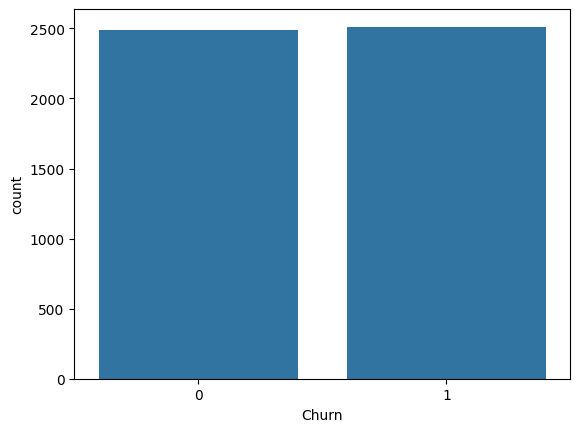

In [76]:
sns.countplot(x='Churn', data=df)
plt.show()

Income vs Churn

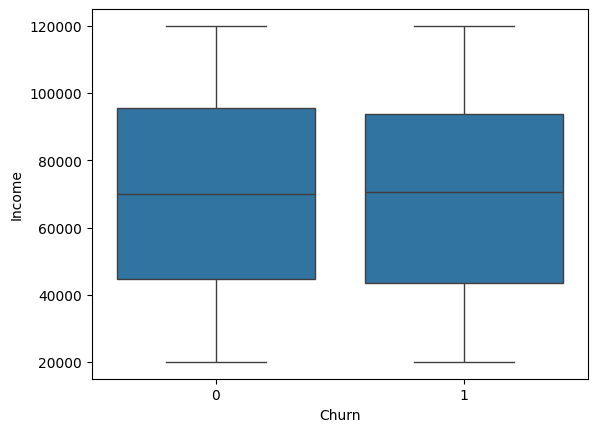

In [77]:
sns.boxplot(x='Churn', y='Income', data=df)
plt.show()

Spending vs Churn

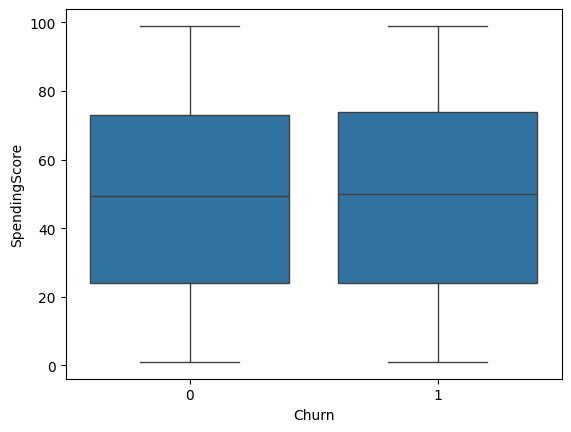

In [78]:
sns.boxplot(x='Churn', y='SpendingScore', data=df)
plt.show()

Correlation Heatmap

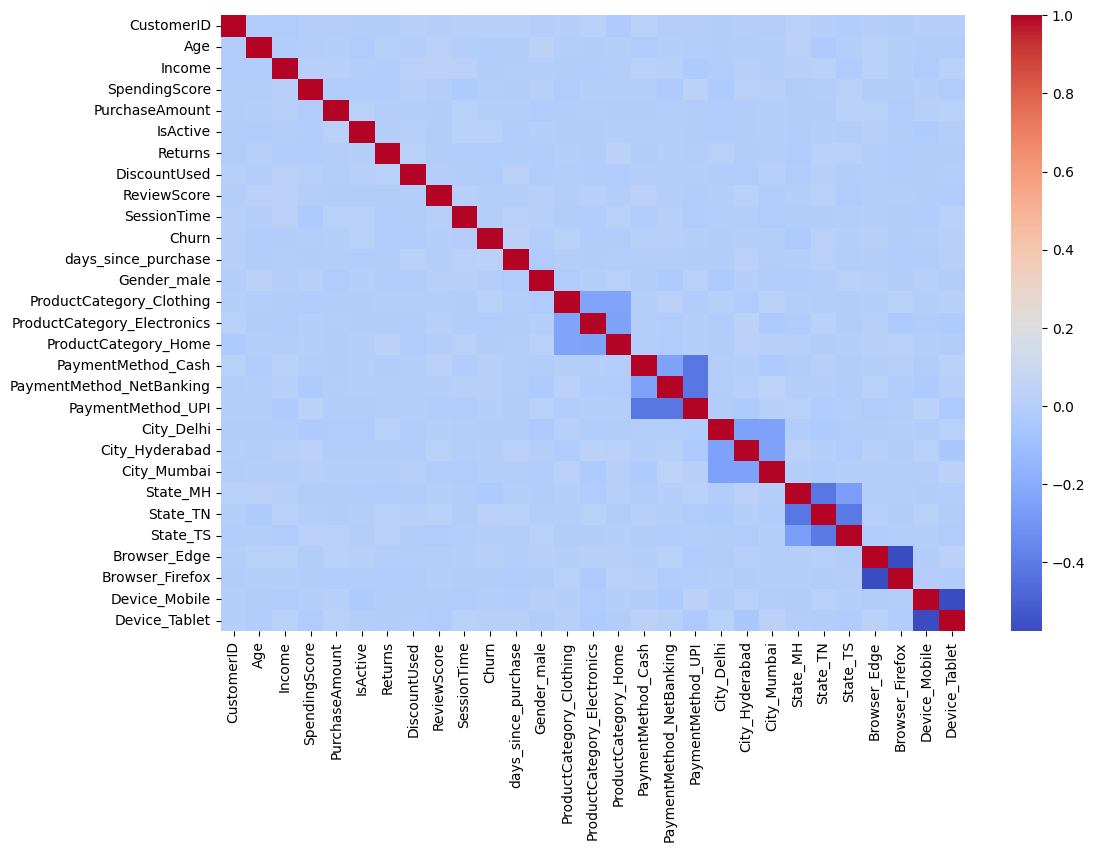

In [79]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [80]:
# FINAL NULL CHECK
print(df.isnull().sum())

# Fill remaining NaNs
df.fillna(0, inplace=True)

CustomerID                     0
Age                            0
Income                         0
SpendingScore                  0
PurchaseAmount                 0
IsActive                       0
Returns                        0
DiscountUsed                   0
ReviewScore                    0
SessionTime                    0
Churn                          0
days_since_purchase            0
Gender_male                    0
ProductCategory_Clothing       0
ProductCategory_Electronics    0
ProductCategory_Home           0
PaymentMethod_Cash             0
PaymentMethod_NetBanking       0
PaymentMethod_UPI              0
City_Delhi                     0
City_Hyderabad                 0
City_Mumbai                    0
State_MH                       0
State_TN                       0
State_TS                       0
Browser_Edge                   0
Browser_Firefox                0
Device_Mobile                  0
Device_Tablet                  0
dtype: int64


SPLIT DATA

In [91]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit ONLY on train
X_test = scaler.transform(X_test)         # transform test

7. Model Training

In [92]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.509   0.504119  0.616935  0.554850
1                  KNN     0.510   0.505769  0.530242  0.517717
2          Naive Bayes     0.491   0.487759  0.522177  0.504382
3                  SVM     0.519   0.514677  0.530242  0.522344
4        Decision Tree     0.528   0.523077  0.548387  0.535433
5        Random Forest     0.511   0.507128  0.502016  0.504559


8. Model Selection

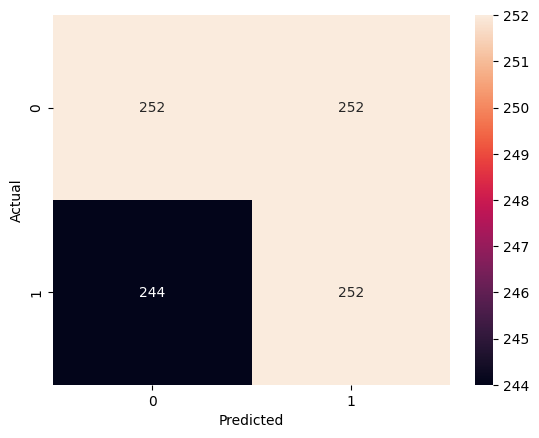

In [84]:
from sklearn.metrics import confusion_matrix
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [93]:
print(df['Churn'].value_counts())

Churn
1    2512
0    2488
Name: count, dtype: int64


In [94]:
rf = RandomForestClassifier()
rf.fit(X, y)

import pandas as pd
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

Income                         0.134966
ReviewScore                    0.131679
PurchaseAmount                 0.130431
SessionTime                    0.124966
SpendingScore                  0.118722
Age                            0.108407
Returns                        0.041482
days_since_purchase            0.027737
Gender_male                    0.020218
IsActive                       0.018577
DiscountUsed                   0.018466
Device_Mobile                  0.018445
PaymentMethod_UPI              0.017521
ProductCategory_Electronics    0.015600
Device_Tablet                  0.015574
ProductCategory_Home           0.014818
ProductCategory_Clothing       0.014430
PaymentMethod_NetBanking       0.014372
PaymentMethod_Cash             0.013590
dtype: float64


In [95]:
top_features = importance.head(8).index
X = X[top_features]

In [96]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [97]:
y_pred = model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.517


In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.48      0.50       504
           1       0.51      0.56      0.53       496

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.52      0.52      0.52      1000



In [100]:
df['spend_per_time'] = df['PurchaseAmount'] / (df['SessionTime'] + 1)
df['engagement'] = df['SessionTime'] * df['IsActive']
df['return_ratio'] = df['Returns'] / (df['PurchaseAmount'] + 1)
df['discount_effect'] = df['DiscountUsed'] * df['PurchaseAmount']

In [101]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

import pandas as pd
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

Income                 0.168969
ReviewScore            0.165875
PurchaseAmount         0.162272
SessionTime            0.153297
SpendingScore          0.142133
Age                    0.131355
Returns                0.046717
days_since_purchase    0.029383
dtype: float64


In [102]:
top_features = importance.head(8).index
X = X[top_features]

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [105]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [106]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [107]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [108]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

SVC(probability=True)

In [109]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200)

In [111]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic": lr,
    "KNN": knn,
    "Naive Bayes": nb,
    "SVM": svm,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score
0       Logistic     0.523   0.518962  0.524194  0.521565
1            KNN     0.466   0.463320  0.483871  0.473373
2    Naive Bayes     0.527   0.519199  0.627016  0.568037
3            SVM     0.529   0.524272  0.544355  0.534125
4  Decision Tree     0.537   0.526829  0.653226  0.583258
5  Random Forest     0.520   0.514870  0.558468  0.535783


Save model: Decision Tree

In [112]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=10)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_split=10)

In [113]:
import pickle

with open("churn_model.pkl", "wb") as f:
    pickle.dump(dt, f)

In [114]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [115]:
with open("features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [117]:
import pickle

features = pickle.load(open("features.pkl", "rb"))
print(features)

['Income', 'ReviewScore', 'PurchaseAmount', 'SessionTime', 'SpendingScore', 'Age', 'Returns', 'days_since_purchase']
